## Aula 1 - Explorando dados com Pandas

### 1. Importar a biblioteca que vamos usar
Vamos utilizar a biblioteca pandas, e apelidá-la como pd

In [1]:
import pandas as pd

### 2. Trazer a base de dados
Agora, vamos definir qual o nosso dataframe (df). É de onde vamos extrair as informações para a análise.

pd - pandas \
read - ler \
_csv - tipo do arquivo, no caso *csv* ou *comma separated values* (pode ser outro tipo de arquivo, como html, json, etc)

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

### 3. Ler a base de dados
O comando head traz as primeiras 4 linhas da base de dados. Caso seja necessário observar mais linhas, podemos adicionar um valor dentro do parênteses. Nesse caso, estamos trabalhando com dados que mostram alguns salários na área de ciência de dados.

In [3]:
df.head(7)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
5,2025.0,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M
6,2025.0,SE,FT,Data Scientist,185000,USD,185000,US,0,US,M


### 4. O comando .info()
Mostra os tipos dos dados de cada coluna (int, float, object, etc). Temos também a coluna de dados não-nulos, que será abordada mais pra frente. Assim, temos uma visão básica dos dados e suas características.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


### 5. O comando .describe()
Traz algumas estatísticas descritivas **dos dados numéricos**. Apenas nos numéricos, considerando que foram feitas análises como média, máximo, mínimo, etc.

In [5]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


### 6. O comando .shape
A dimensão do arquivo. Temos um resultado na forma (linha, coluna).

In [6]:
df.shape

(133349, 11)

In [7]:
linhas, colunas = df.shape[0], df.shape[1]
print("O número de linhas é", linhas, "e o número de colunas é", colunas)


O número de linhas é 133349 e o número de colunas é 11


### 7. Listar os nomes das colunas
Mostra os nomes de cada coluna do dataframe

In [8]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

### 8. Alterando os nomes das colunas
Vamos traduzir as colunas da base de dados, para acessar os dados mais facilmente. A parte 'inplace = True' define que não é preciso criar um novo dataframe, ou seja, os nomes alterados são do próprio dataframe *df*.

In [9]:
renomear_colunas = {
    'work_year': 'ano_de_trabalho',
    'experience_level': 'nivel_de_exp',
    'employment_type': 'tipo_de_emprego',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda_do_salario',
    'salary_in_usd': 'salario_em_usd',
    'employee_residence': 'resid_do_funcionario',
    'remote_ratio': 'taxa_remoto',
    'company_location': 'local_empresa',
    'company_size': 'tamanho_empresa'
}

df.rename(columns = renomear_colunas, inplace = True)
df.columns

Index(['ano_de_trabalho', 'nivel_de_exp', 'tipo_de_emprego', 'cargo',
       'salario', 'moeda_do_salario', 'salario_em_usd', 'resid_do_funcionario',
       'taxa_remoto', 'local_empresa', 'tamanho_empresa'],
      dtype='object')

### 9. Analisando as colunas
Como exemplo, vamos analisar a coluna de nível de senioridade. \
\
Vamos primeiro verificar qual o nível de experiência mais comum, usando o value_counts(). \
(SE - Sênior, MI - Mid/Pleno, EN - Entue/Júnior, EX - Executive/Gerência). \
\
Depois, vamos analisar os tipos de emprego, ainda com o value_counts(). \
(FT - Full Time, CT - Contrato Temporário, PT - Part Time, FL - Freelance) \
\
Depois, vamos observar o tipo de trabalho, comparando a quantidade de pessoas que trabalham remotamente(100), com um modelo híbrido(50) ou presencialmente(0). \
\
Então, vamos analisar o tamanho das empresas. Estão divididas entre: pequena - S, média - M e grande - G

In [10]:
df['nivel_de_exp'].value_counts()

,count
nivel_de_exp,
SE,77241
MI,40465
EN,12443
EX,3200


In [11]:
df['tipo_de_emprego'].value_counts()

,count
tipo_de_emprego,
FT,132563
CT,394
PT,376
FL,16


In [12]:
df['taxa_remoto'].value_counts()

,count
taxa_remoto,
0,105312
100,27718
50,319


In [13]:
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
M,129561
L,3574
S,214


### 10. Renomeando as categorias de algumas colunas
Em vez de usar o .rename com o inplace = True, podemos utilizar o .replace

In [14]:
sub_experiencia = {
    'SE': 'Sênior',
    'MI': 'Pleno',
    'EN': 'Junior',
    'EX': 'Executivo'
}

df['nivel_de_exp'] = df['nivel_de_exp'].replace(sub_experiencia)
df['nivel_de_exp'].value_counts()

,count
nivel_de_exp,
Sênior,77241
Pleno,40465
Junior,12443
Executivo,3200


In [15]:
sub_tipo_de_emp = {
    'FT': 'Integral',
    'PT': 'Meio Periodo',
    'FL': 'Freelance',
    'CT': 'Contrato Temporario'
}

df['tipo_de_emprego'] = df['tipo_de_emprego'].replace(sub_tipo_de_emp)
df['tipo_de_emprego'].value_counts()

,count
tipo_de_emprego,
Integral,132563
Contrato Temporario,394
Meio Periodo,376
Freelance,16


In [16]:
sub_remoto = {
    0: 'Presencial',
    50: 'Hibrido',
    100: 'Remoto'
}

df['taxa_remoto'] = df['taxa_remoto'].replace(sub_remoto)
df['taxa_remoto'].value_counts()

,count
taxa_remoto,
Presencial,105312
Remoto,27718
Hibrido,319


In [17]:
sub_tam_empresa = {
    'S': 'Pequena',
    'M': 'Média',
    'L': 'Grande'
}

df['tamanho_empresa'] = df['tamanho_empresa'].replace(sub_tam_empresa)
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
Média,129561
Grande,3574
Pequena,214


### 11. Novo layout do dataframe
Podemos ver as alterações para nomes em português(com exceção dos nomes de cargos) e também a descrição dos objetos (valores não-numéricos) \
\
**count** - contagem de quantos valores existem para aquela coluna (valores não nulos!) \
**unique** - conta quantos valores únicos existem em cada coluna \
**top** - qual informação é a mais frequente \
**freq** - quantas vezes o valor mais frequente se repete

In [18]:
df.head(10)

,ano_de_trabalho,nivel_de_exp,tipo_de_emprego,cargo,salario,moeda_do_salario,salario_em_usd,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
0,2025.0,Sênior,Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Junior,Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média
5,2025.0,Junior,Integral,Data Engineer,80000,USD,80000,US,Presencial,US,Média
6,2025.0,Sênior,Integral,Data Scientist,185000,USD,185000,US,Presencial,US,Média
7,2025.0,Sênior,Integral,Data Scientist,148000,USD,148000,US,Presencial,US,Média
8,2025.0,Pleno,Integral,Data Scientist,135000,USD,135000,CA,Presencial,CA,Média
9,2025.0,Pleno,Integral,Data Scientist,108000,USD,108000,CA,Presencial,CA,Média


In [19]:
df.describe(include = 'object')

,nivel_de_exp,tipo_de_emprego,cargo,moeda_do_salario,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,Sênior,Integral,Data Scientist,USD,US,Presencial,US,Média
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [20]:
df.describe()

,ano_de_trabalho,salario,salario_em_usd
count,133339.000000,1.333490e+05,133349.000000
mean,2024.358770,1.632833e+05,157617.272098
std,0.680627,2.173860e+05,74288.363097
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060200e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


### 12. Considerações Finais Pós-Aula
Com as análises acima, já conseguimos responder algumas perguntas como:


*   Qual o nível de experiência mais comum na base de dados?
*   Qual é o tipo de contrato mais frequente?
*   Qual o cargo mais frequente na amostra?
*   De qual país são a maioria dos profissionais da base?
*   Qual é o país onde mais empresas da amostra estão sediadas?
*   Qual o regime de trabalho mais comum?
*   Qual é o tamanho mais comum das empresas na amostra?

## Aula 2 - Limpeza e Preparação de Dados

### 1. Verificando onde há dados nulos
Onde tiver algum dado, teremos a resposta 'False'.
Além disso, com o .sum(), podemos ver quantos dados de uma coluna estão ausentes.

In [21]:
df.head()

,ano_de_trabalho,nivel_de_exp,tipo_de_emprego,cargo,salario,moeda_do_salario,salario_em_usd,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
0,2025.0,Sênior,Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Junior,Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [22]:
df.isnull()

,ano_de_trabalho,nivel_de_exp,tipo_de_emprego,cargo,salario,moeda_do_salario,salario_em_usd,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [23]:
df.isnull().sum()

,0
ano_de_trabalho,10
nivel_de_exp,0
tipo_de_emprego,0
cargo,0
salario,0
moeda_do_salario,0
salario_em_usd,0
resid_do_funcionario,0
taxa_remoto,0
local_empresa,0


### 2. Dados únicos
Vemos que uma das opções de dados de 'ano_de_trabalho' é nan, que significa que algumas linhas não tem a informação do ano de trabalho.

In [24]:
df['ano_de_trabalho'].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

### 3. Verificando quais linhas tem algum dado nulo
Quero aplicar um filtro na base de dados df. Esse filtro está dentro do [], que é o filtro df.isnull(). Em seguida, ele aplica o método any(), especificando axis=1 (dimensão = 1). Isso significa que ele verifica cada linha individualmente. Se qualquer valor em uma linha for True (ou seja, se houver qualquer valor nulo nessa linha), ele retorna True para essa linha. \
\
Encontrar e preencher/excluir/inputar me baseando em regras as lacunas de uma base de dados nos ajuda a tomar melhores decisões (além de auxiliar no caso da alimentação de uma ferramenta de inteligência artificial, por exemplo).

In [25]:
df[df.isnull().any(axis=1)]

,ano_de_trabalho,nivel_de_exp,tipo_de_emprego,cargo,salario,moeda_do_salario,salario_em_usd,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
5588,NaN,Sênior,Integral,Product Manager,184500,USD,184500,US,Presencial,US,Média
59692,NaN,Pleno,Integral,Engineer,110000,USD,110000,DE,Presencial,DE,Média
59710,NaN,Junior,Integral,Data Scientist,208800,USD,208800,US,Presencial,US,Média
59759,NaN,Sênior,Integral,Software Engineer,135000,USD,135000,US,Presencial,US,Média
59789,NaN,Sênior,Integral,Engineer,112000,USD,112000,US,Presencial,US,Média
131000,NaN,Sênior,Integral,Machine Learning Engineer,163800,USD,163800,US,Presencial,US,Média
131006,NaN,Sênior,Integral,Data Analytics Manager,204500,USD,204500,US,Presencial,US,Média
133054,NaN,Junior,Integral,Data Scientist,40000,USD,40000,JP,Remoto,MY,Grande
133281,NaN,Pleno,Integral,Machine Learning Engineer,180000,PLN,46597,PL,Remoto,PL,Grande
133317,NaN,Pleno,Integral,Data Scientist,130000,USD,130000,US,Hibrido,US,Grande


### 4. Substituindo os valores nulos com a média dos valores conhecidos

Usaremos a biblioteca numpy, a fim de utilizar o np.nan para indicar a ausência de informação, e criamos uma mini base de dados pra ilustrar como funciona esse preenchimento usando a média dos salários.\
\
No caso de termos uma base de dados com muita disparidade entre os valores, e muita quantidade, podemos também utilizar a mediana para substituir esses valores nulos. \
\
Depois, criaremos outra base de dados, para analisar a flutuação de temperaturas máximas ao longo de uma certa quantidade de dias, e vamos testar os métodos ffill (forward fill) e bfill (backward fill). \
\
Por fim, teremos uma terceira base de dados, tratando de nomes de cidades. Nela, apenas preencheremos as informações nulas com "Não informado".

In [26]:
import numpy as np

df_salarios = pd.DataFrame({
    'nome': ["Ana", "Bruno", "Carlos", "Daniel", "Eliana"],
    'salario': [4000, np.nan, 5000, np.nan, 10000]
})

# Calcula a média salarial, e substitui os nulos (Arredonda os valores)
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))

df_salarios

,nome,salario,salario_media
0,Ana,4000.0,4000.00
1,Bruno,NaN,6333.33
2,Carlos,5000.0,5000.00
3,Daniel,NaN,6333.33
4,Eliana,10000.0,10000.00


In [27]:
# Calcula a mediana salarial, e substitui os nulos (Arredonda os valores)
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].median())

df_salarios

,nome,salario,salario_media
0,Ana,4000.0,4000.0
1,Bruno,NaN,5000.0
2,Carlos,5000.0,5000.0
3,Daniel,NaN,5000.0
4,Eliana,10000.0,10000.0


In [28]:
df_temperaturas = pd.DataFrame({
    "Dias": ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    "Temperatura": [30, np.nan, np.nan, 28, 27]
})

# ffill (ou forward fill) preenche com o valor anterior ao da posição vazia
df_temperaturas["preenchido_ffill"] = df_temperaturas["Temperatura"].ffill()

df_temperaturas

,Dias,Temperatura,preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,30.0
2,Quarta,NaN,30.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [29]:
df_temperaturas = pd.DataFrame({
    "Dias": ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    "Temperatura": [30, np.nan, np.nan, 28, 27]
})

# bfill (ou backward fill) preenche com o valor posterior ao da posição vazia
df_temperaturas["preenchido_ffill"] = df_temperaturas["Temperatura"].bfill()

df_temperaturas

,Dias,Temperatura,preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,28.0
2,Quarta,NaN,28.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [30]:
df_cidades = pd.DataFrame({
    "nome": ["Ana", "Bruno", "Carlos", "Daniel", "Eliana"],
    "cidade": ["São Paulo", np.nan, "Curitiba", np.nan, "Belém"]
})

df_cidades["cidade_preenchida"] = df_cidades["cidade"].fillna("Não informado")

df_cidades

,nome,cidade,cidade_preenchida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Daniel,NaN,Não informado
4,Eliana,Belém,Belém


### 5. Limpando e tratando os dados do Data Frame original

Vamos criar um novo data frame, igual ao original, a fim de realizar mudanças sem modificar a base original. Primeiro, usaremos o dropna() para remover as linhas com informações nulas. Depois, faremos uma alteração no tipo de variável do 'ano_de_trabalho', transformando o float em int.

In [31]:
df_limpo = df.dropna()

In [32]:
df_limpo.isnull().sum()

,0
ano_de_trabalho,0
nivel_de_exp,0
tipo_de_emprego,0
cargo,0
salario,0
moeda_do_salario,0
salario_em_usd,0
resid_do_funcionario,0
taxa_remoto,0
local_empresa,0


In [33]:
df_limpo.head()
# Aqui, podemos ver que o ano de trabalho está como 2025.0, e não 2025

,ano_de_trabalho,nivel_de_exp,tipo_de_emprego,cargo,salario,moeda_do_salario,salario_em_usd,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
0,2025.0,Sênior,Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Junior,Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [34]:
df_limpo.info()
# O ano de trabalho está como um valor float64. Podemos converter isso pra int64.

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ano_de_trabalho       133339 non-null  float64
 1   nivel_de_exp          133339 non-null  object 
 2   tipo_de_emprego       133339 non-null  object 
 3   cargo                 133339 non-null  object 
 4   salario               133339 non-null  int64  
 5   moeda_do_salario      133339 non-null  object 
 6   salario_em_usd        133339 non-null  int64  
 7   resid_do_funcionario  133339 non-null  object 
 8   taxa_remoto           133339 non-null  object 
 9   local_empresa         133339 non-null  object 
 10  tamanho_empresa       133339 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.2+ MB


In [35]:
# A coluna "ano_de_trabalho" recebe a mesma coluna ano, mas como int64
df_limpo = df_limpo.assign(ano_de_trabalho = df_limpo["ano_de_trabalho"].astype("int64"))
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   ano_de_trabalho       133339 non-null  int64 
 1   nivel_de_exp          133339 non-null  object
 2   tipo_de_emprego       133339 non-null  object
 3   cargo                 133339 non-null  object
 4   salario               133339 non-null  int64 
 5   moeda_do_salario      133339 non-null  object
 6   salario_em_usd        133339 non-null  int64 
 7   resid_do_funcionario  133339 non-null  object
 8   taxa_remoto           133339 non-null  object
 9   local_empresa         133339 non-null  object
 10  tamanho_empresa       133339 non-null  object
dtypes: int64(3), object(8)
memory usage: 12.2+ MB


## Aula 3 - Storytelling com Dados

### 1. Visualizando dados
Usando o .plot(), podemos visualizar a distribuição de dados em um gráfico. Nesse caso específico, verificamos quantas pessoas da base de dados trabalham em uma das 4 posições 'Senior', 'Pleno', 'Junior' e 'Executivo'.

In [36]:
df_limpo.head()

,ano_de_trabalho,nivel_de_exp,tipo_de_emprego,cargo,salario,moeda_do_salario,salario_em_usd,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
0,2025,Sênior,Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Sênior,Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Junior,Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


<Axes: title={'center': 'Senioridade (Distribuição)'}, xlabel='nivel_de_exp'>

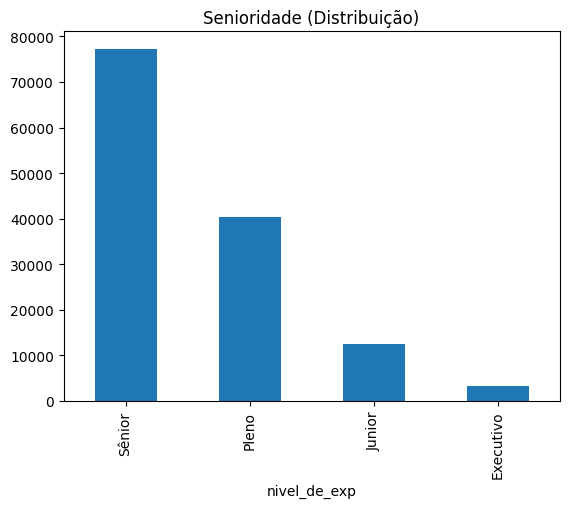

In [37]:
df_limpo['nivel_de_exp'].value_counts().plot(kind='bar', title = 'Senioridade (Distribuição)')

### 2. Usando a biblioteca Seaborn
Vamos usar essa biblioteca para, por exemplo, visualizar a média salarial de cada um dos níveis de experiência.

In [38]:
import seaborn as sns

<Axes: xlabel='nivel_de_exp', ylabel='salario_em_usd'>

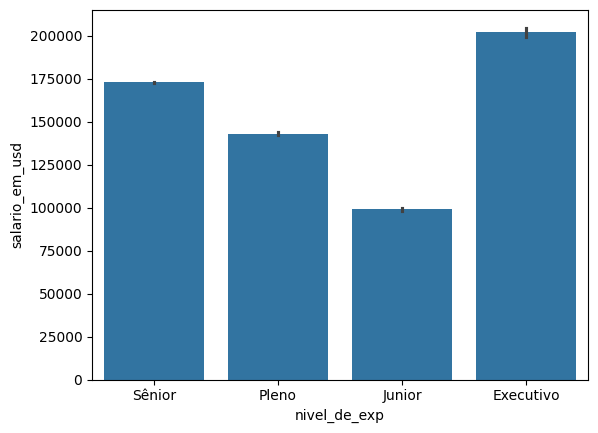

In [39]:
sns.barplot(data = df_limpo, x = 'nivel_de_exp', y = 'salario_em_usd')

### 3. Usando Matplotlib como auxiliar
No caso, usaremos especificamente o módulo pyplot para manipular e visualizar melhor o exemplo anterior, além de ver vários outros exemplos.

In [40]:
import matplotlib.pyplot as plt


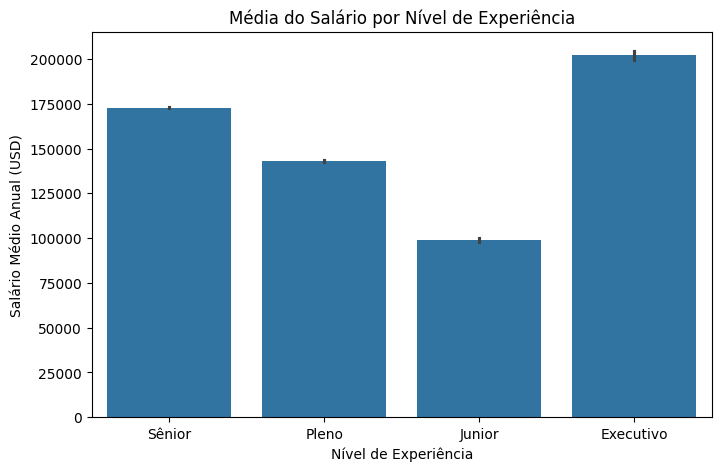

In [41]:
plt.figure(figsize = (8,5))
sns.barplot(data = df_limpo, x = 'nivel_de_exp', y = 'salario_em_usd')
plt.title('Média do Salário por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário Médio Anual (USD)')
plt.show()

In [42]:
# Média dos valores(media em usd dos salarios) usando a biblioteca Pandas. Valores decrescentes.
# Mostra uma lista chamada 'ordem', que mostra os niveis de senioridade em ordem dec. de media de salarios
# Usando o True ou o False, podemos ver em ordem crescente ou decrescente
ordem = df_limpo.groupby('nivel_de_exp')['salario_em_usd'].mean().sort_values(ascending = True).index
ordem

Index(['Junior', 'Pleno', 'Sênior', 'Executivo'], dtype='object', name='nivel_de_exp')

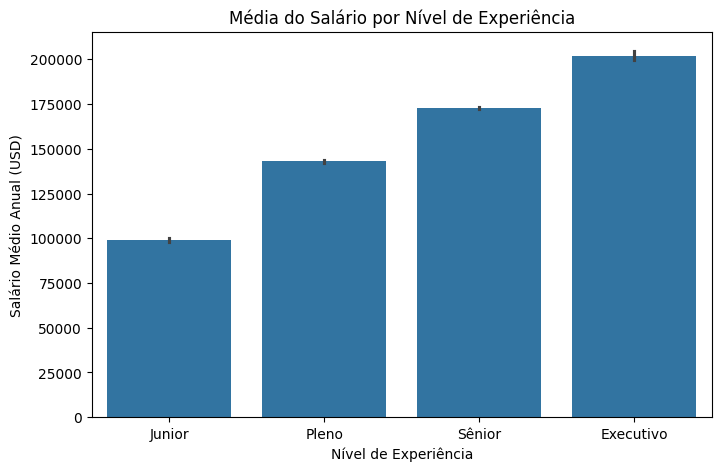

In [43]:
plt.figure(figsize = (8,5))
# Adiciono a ordem estabelecida
sns.barplot(data = df_limpo, x = 'nivel_de_exp', y = 'salario_em_usd', order = ordem)
plt.title('Média do Salário por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário Médio Anual (USD)')
plt.show()

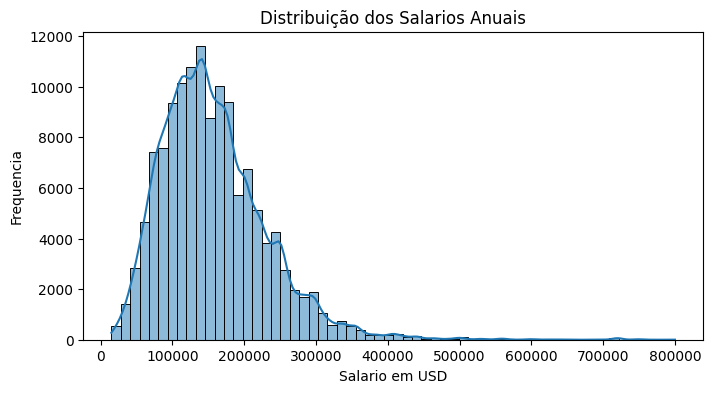

In [44]:
# Histograma dos salarios anuais
# Os dados, em sua maioria, estão perto do lado esquerdo do gráfico
# Além disso, não temos uma distribuição normal
plt.figure(figsize = (8,4))
sns.histplot(data = df_limpo['salario_em_usd'], bins = 60, kde = True)
plt.title('Distribuição dos Salarios Anuais')
plt.xlabel('Salario em USD')
plt.ylabel('Frequencia')
plt.show()

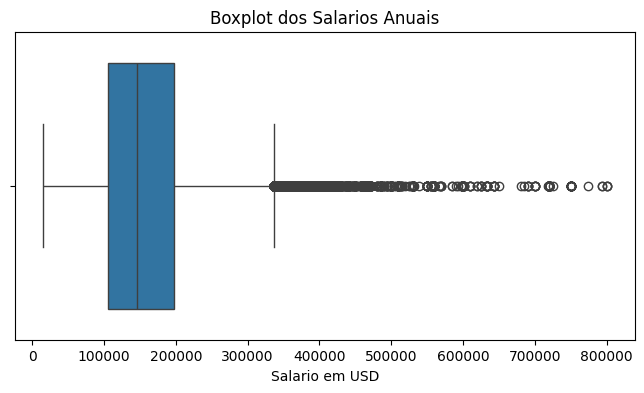

In [45]:
# Um gráfico mais técnico, não ideal para uma reunião geral
# Os pontinhos, chamados 'outliers' são os valores que estão fora da região principal
# É complementar ao histograma
plt.figure(figsize = (8,4))
sns.boxplot(x = df_limpo['salario_em_usd'])
plt.title('Boxplot dos Salarios Anuais')
plt.xlabel('Salario em USD')
plt.show()

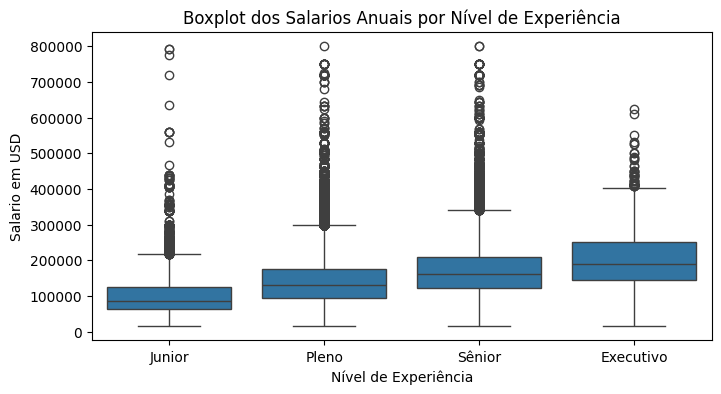

In [46]:
ordem_senioridade = ['Junior', 'Pleno', 'Sênior', 'Executivo']

plt.figure(figsize = (8,4))
sns.boxplot(data = df_limpo, x = 'nivel_de_exp', y = 'salario_em_usd', order = ordem_senioridade)
plt.title('Boxplot dos Salarios Anuais por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salario em USD')
plt.show()

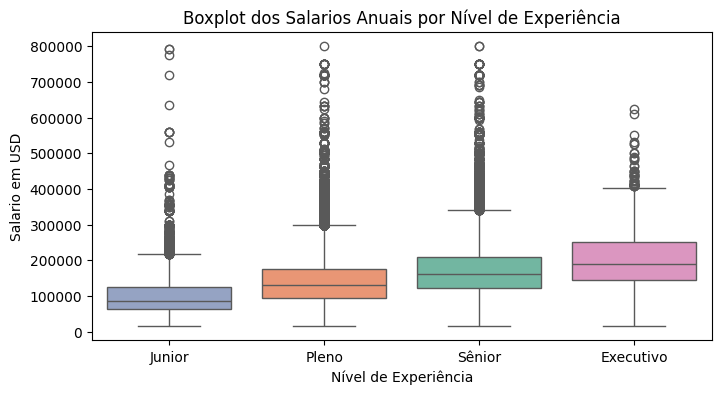

In [47]:
ordem_senioridade = ['Junior', 'Pleno', 'Sênior', 'Executivo']

plt.figure(figsize = (8,4))
sns.boxplot(data = df_limpo, x = 'nivel_de_exp', y = 'salario_em_usd', order = ordem_senioridade, palette = 'Set2', hue = 'nivel_de_exp')
plt.title('Boxplot dos Salarios Anuais por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salario em USD')
plt.show()

### 4. Usando a plotly

Vamos usar a biblioteca plotly, para gráficos interativos.

In [48]:
import plotly.express as px

In [49]:
senioridade_media_salario = df_limpo.groupby('nivel_de_exp')['salario_em_usd'].mean().sort_values(ascending = True).reset_index()

fig = px.bar(senioridade_media_salario,
             x = 'nivel_de_exp',
             y = 'salario_em_usd',
             title = 'Média Salarial por Nível de Experiência',
             labels = {'nivel_de_exp': 'Nível de Senioridade',
                       'salario_em_usd': 'Média Salarial Anual (USD)'})

fig.show()

In [50]:
remoto_contagem = df_limpo['taxa_remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_de_trabalho', 'contagem']

fig = px.pie(remoto_contagem,
             names = 'tipo_de_trabalho',
             values = 'contagem',
             title = 'Contagem de Tipos de Trabalho',
             hole = 0.5,
             labels = {'tipo_de_trabalho': 'Tipo de Trabalho',
                       'contagem': 'Contagem'})

fig.update_traces(textinfo = 'percent+label')
fig.show()

In [51]:
# Exercício: Gerar um gráfico com o plotly que mostre a média de salários
# de um cientista de dados por país

# Primeiro, eu filtro o dataframe para conter apenas os dados de cientistas de dados
df_data_scientist = df_limpo[df_limpo['cargo'] == 'Data Scientist']
# Depois, agrupo por local da empresa, e calculo a media salarial por país
salario_medio_data_scientist_por_pais = df_data_scientist.groupby('local_empresa')['salario_em_usd'].mean().sort_values(ascending=True).reset_index()

fig = px.bar(salario_medio_data_scientist_por_pais,
             x = 'local_empresa',
             y = 'salario_em_usd',
             color = 'local_empresa', # Adiciona cores às barras com base no local da empresa
             title = 'Média Salarial de Data Scientists por País',
             labels = {'local_empresa': 'Local da Empresa',
                       'salario_em_usd': 'Salário Médio Anual (USD)'})

fig.show()

In [52]:
# Outra maneira de resolver o exercício: pycountry!
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 99.1 MB/s eta 0:00:00


In [53]:
import pycountry

# Convertemos ISO-2 para ISO-3
def iso2_para_iso3(codigo_iso2):
    try:
        pais = pycountry.countries.get(alpha_2=codigo_iso2)
        return pais.alpha_3
    except:
        return None

# Adiciono a coluna com o código ISO-3
salario_medio_data_scientist_por_pais['res_iso3_local_empresa'] = salario_medio_data_scientist_por_pais['local_empresa'].apply(iso2_para_iso3)

# Gero o mapa
fig = px.choropleth(salario_medio_data_scientist_por_pais,
                    locations = 'res_iso3_local_empresa',
                    color = 'salario_em_usd',
                    color_continuous_scale= 'rdylgn',
                    title = 'Média Salarial de Data Scientists por País',
                    labels = {'salario_em_usd': 'Salário Médio Anual (USD)'})

fig.show()

### 5. Baixando a base de dados (limpa)

In [54]:
df_limpo.to_csv('df_limpo.csv', index = False)

In [55]:
df_limpo.head()

,ano_de_trabalho,nivel_de_exp,tipo_de_emprego,cargo,salario,moeda_do_salario,salario_em_usd,resid_do_funcionario,taxa_remoto,local_empresa,tamanho_empresa
0,2025,Sênior,Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Sênior,Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Junior,Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média
